# KuaiRec: exploratory analysis

**Question:** what does engagement look like on a short-video feed, and what does that imply
for how we *label*, *split* and *evaluate* a recommender?

Inputs are the validated tables built by `dvc repro` (`data/processed/`, `data/splits/`).
Figures are also saved to `reports/figures/` for the README. Re-run with `make eda`.

**Test-set hygiene:** analyses of the fully observed matrix use only the *tune* users. The
*test* users (80% of the fully observed matrix) are never opened in this notebook.

In [1]:
import json
from datetime import date
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import polars as pl
from matplotlib.axis import Axis

from recsys.data.categories import with_english_category_names
from recsys.data.labels import positive_rate_by_length
from recsys.evaluation.concentration import gini, lorenz_curve, top_share
from recsys.viz import style


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dvc.yaml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_repo_root(Path.cwd())
PROCESSED, SPLITS, FIGURES = ROOT / "data/processed", ROOT / "data/splits", ROOT / "reports/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
NAIVE_THRESHOLD = 2.0  # the dataset authors' suggested "like" cut-off on watch_ratio
SLICE_WIDTH_RATIO, SLICE_MIN_VIEWS = 1.1, 2000  # fine length slices for bias checks
MIN_LOGGED_VIEWS = 30  # videos need this many logged views for a stable logged rate
BUSY_DAY_MIN_VIEWS = 10_000  # days below this hold only stray events
FIGSIZE = (8, 4.2)
style.apply_style()


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES / f"{name}.png")
    plt.show()
    plt.close(fig)


def decile(column: str) -> pl.Expr:
    """0-9 equal-frequency bucket of ``column``."""
    return ((pl.col(column).rank("ordinal").cast(pl.Int64) - 1) * 10 // pl.len()).cast(pl.Int32)


def spearman(df: pl.DataFrame, a: str, b: str) -> float:
    return df.select(pl.corr(a, b, method="spearman")).item()


def label_end(ax: plt.Axes, x: float, y: float, text: str) -> None:
    ax.annotate(
        text,
        (x, y),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        color=style.INK_SECONDARY,
        fontsize=9,
    )


def percent_axis(axis: Axis) -> None:
    axis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

In [2]:
big = pl.read_parquet(PROCESSED / "big_matrix.parquet")
small = pl.read_parquet(PROCESSED / "small_matrix.parquet")  # counts only, no labels
train = pl.read_parquet(SPLITS / "train.parquet")
tune = pl.read_parquet(SPLITS / "tune.parquet")  # fully observed, tune users only
captions = with_english_category_names(pl.read_parquet(PROCESSED / "video_captions.parquet"))
split_summary = json.loads((ROOT / "reports/split_summary.json").read_text(encoding="utf-8"))
QUANTILE = split_summary["label"]["quantile"]
N_LABEL_BUCKETS = len(split_summary["label"]["watch_ratio_thresholds"])
VALID_START = date.fromisoformat(split_summary["valid_start"])

## 1. Two matrices with two different jobs

* **big_matrix** is the *logged feed*: what the platform's own recommender chose to show.
  It is sparse and shaped by that recommender's choices. We train on it.
* **small_matrix** is *fully observed*: a fixed set of users was shown (almost) every video
  in a fixed set. Exposure there was not chosen by any recommender, so it is the honest place
  to evaluate one, and the basis of the A/B simulation later.

In [3]:
def matrix_profile(name: str, df: pl.DataFrame) -> dict:
    users, videos = df["user_id"].n_unique(), df["video_id"].n_unique()
    return {
        "table": name,
        "views": df.height,
        "users": users,
        "videos": videos,
        "density": round(df.select("user_id", "video_id").n_unique() / (users * videos), 3),
        "min views per user": df.group_by("user_id").len()["len"].min(),
    }


pl.DataFrame(
    [
        matrix_profile("big_matrix (logged feed)", big),
        matrix_profile("small_matrix (fully observed)", small),
    ]
)

table,views,users,videos,density,min views per user
str,i64,i64,i64,f64,i64
"""big_matrix (logged feed)""",11562802,7176,10728,0.134,94
"""small_matrix (fully observed)""",4676570,1411,3327,0.996,3295


Every user is a heavy user, so cold-start *users* are not a concern in this dataset.

## 2. The engagement signal: `watch_ratio`

`watch_ratio` = time watched ÷ video length. A value of 1 means the video was watched to the
end; values above 1 mean it looped.

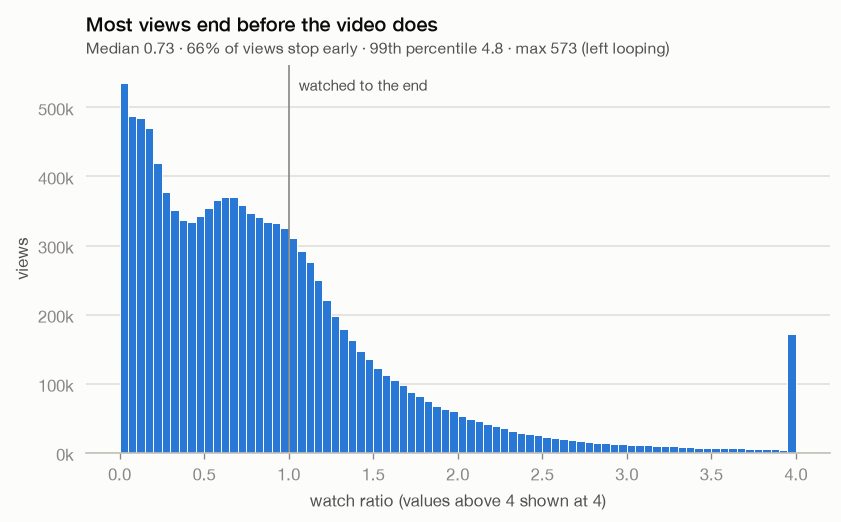

In [4]:
ratio = big["watch_ratio"]
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(
    ratio.clip(upper_bound=4).to_numpy(),
    bins=80,
    range=(0, 4),
    color=style.PRIMARY,
    edgecolor=style.SURFACE,
    linewidth=0.6,
)
ax.axvline(1, color=style.INK_MUTED, linewidth=1)
ax.annotate(
    "watched to the end",
    (1, 0.97),
    xycoords=("data", "axes fraction"),
    xytext=(6, 0),
    textcoords="offset points",
    va="top",
    color=style.INK_SECONDARY,
    fontsize=9,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}k"))
ax.set_xlabel("watch ratio (values above 4 shown at 4)")
ax.set_ylabel("views")
style.add_title(
    ax,
    "Most views end before the video does",
    f"Median {ratio.median():.2f} · {ratio.lt(1).mean():.0%} of views stop early · "
    f"99th percentile {ratio.quantile(0.99):.1f} · max {ratio.max():.0f} (left looping)",
)
save(fig, "01_watch_ratio_distribution")

## 3. Duration bias: `watch_ratio` mostly measures how short a video is

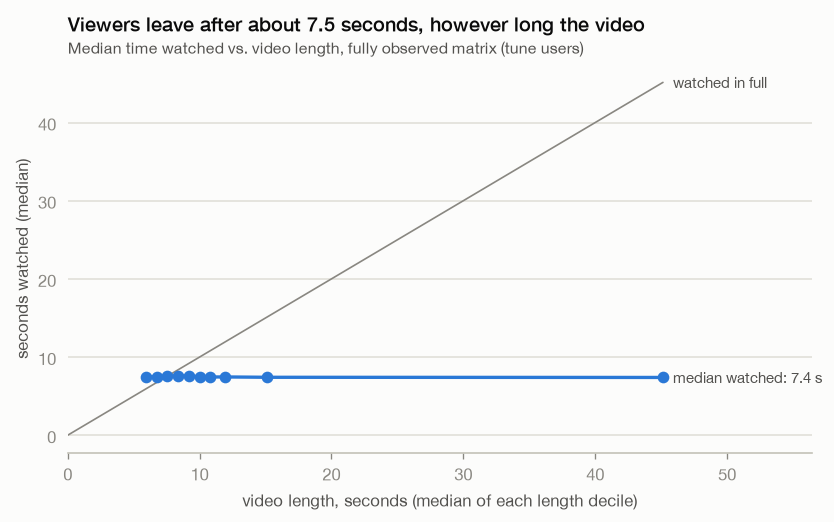

In [5]:
by_length = (
    tune.with_columns(length_decile=decile("video_duration"))
    .group_by("length_decile")
    .agg(
        length_s=pl.col("video_duration").median() / 1000,
        watched_s=pl.col("play_duration").median() / 1000,
    )
    .sort("length_decile")
)
x, watched = by_length["length_s"].to_list(), by_length["watched_s"].to_list()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot([0, max(x)], [0, max(x)], color=style.INK_MUTED, linewidth=1)
label_end(ax, max(x), max(x), "watched in full")
ax.plot(x, watched, marker="o", color=style.PRIMARY)
label_end(ax, x[-1], watched[-1], f"median watched: {watched[-1]:.1f} s")
ax.set_xlim(0, max(x) * 1.25)
ax.set_xlabel("video length, seconds (median of each length decile)")
ax.set_ylabel("seconds watched (median)")
style.add_title(
    ax,
    f"Viewers leave after about {tune['play_duration'].median() / 1000:.1f} seconds, "
    "however long the video",
    "Median time watched vs. video length, fully observed matrix (tune users)",
)
save(fig, "02_time_watched_vs_length")

Because time watched is roughly constant, `watch_ratio ≈ constant ÷ length`. A label such as
"watch_ratio ≥ 2" therefore fires mostly for very short videos, and any model trained on it
would learn "recommend short videos".

**The label used in this project.** Video lengths are cut into log-spaced buckets, each at most
15% wide (so length can move the watch ratio by at most ~15% inside a bucket); sparse lengths
are merged until every bucket has 10,000 training views. A view is positive when its watch
ratio is above the training quantile for its bucket. This follows the duration-bucketing idea of
D2Q (*Zhan et al., KDD 2022*), applied to the watch ratio rather than raw play time.

The check below uses fine 10%-wide length slices of the fully observed tune users. An earlier
version with 10 equal-frequency buckets looked flat at that resolution but hid a 60× bias
inside its widest (23 s to 5 min) bucket, which is why the check uses much finer slices than
the label itself.

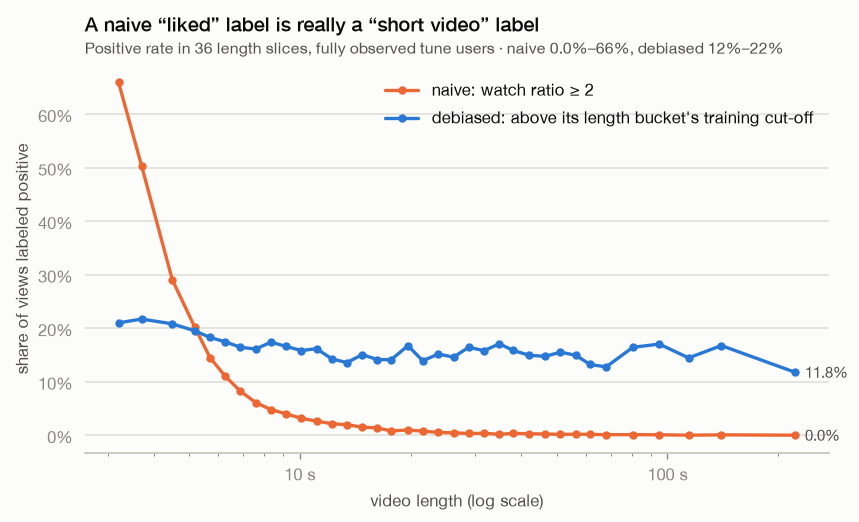

In [6]:
naive = positive_rate_by_length(
    tune.with_columns(is_positive=pl.col("watch_ratio") >= NAIVE_THRESHOLD),
    width_ratio=SLICE_WIDTH_RATIO,
    min_views=SLICE_MIN_VIEWS,
)
debiased = positive_rate_by_length(tune, width_ratio=SLICE_WIDTH_RATIO, min_views=SLICE_MIN_VIEWS)
slice_mid_s = (debiased["length_min_s"] * debiased["length_max_s"]).sqrt().to_list()

fig, ax = plt.subplots(figsize=FIGSIZE)
for rates, color, name in (
    (naive, style.SECONDARY, f"naive: watch ratio ≥ {NAIVE_THRESHOLD:g}"),
    (debiased, style.PRIMARY, "debiased: above its length bucket's training cut-off"),
):
    values = rates["positive_rate"].to_list()
    ax.plot(slice_mid_s, values, marker="o", markersize=4, color=color, label=name)
    label_end(ax, slice_mid_s[-1], values[-1], f"{values[-1]:.1%}")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g} s"))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
percent_axis(ax.yaxis)
ax.set_xlabel("video length (log scale)")
ax.set_ylabel("share of views labeled positive")
ax.legend(loc="upper right")
style.add_title(
    ax,
    "A naive “liked” label is really a “short video” label",
    f"Positive rate in {debiased.height} length slices, fully observed tune users · naive "
    f"{naive['positive_rate'].min():.1%}–{naive['positive_rate'].max():.0%}, debiased "
    f"{debiased['positive_rate'].min():.0%}–{debiased['positive_rate'].max():.0%}",
)
save(fig, "03_label_positive_rate_by_length")

The base rate also shifts between data sources: cut-offs are fitted on the logged feed, where
exactly the top 20% of views are positive by construction, but fewer views clear them in the
fully observed matrix. The platform's recommender showed people videos they were more likely
to watch, so the logged feed is already enriched for engagement.

In [7]:
pl.DataFrame(
    [
        {
            "split": name,
            "source": source,
            "positive rate": split_summary[name]["positive_rate"],
            "rate across length slices": (
                f"{split_summary[name]['length_balance']['min_positive_rate']:.1%} – "
                f"{split_summary[name]['length_balance']['max_positive_rate']:.1%}"
            ),
        }
        for name, source in (
            ("train", "logged feed"),
            ("valid", "logged feed"),
            ("tune", "fully observed"),
        )
    ]
)

split,source,positive rate,rate across length slices
str,str,f64,str
"""train""","""logged feed""",0.2,"""16.2% – 25.1%"""
"""valid""","""logged feed""",0.2112,"""17.0% – 26.1%"""
"""tune""","""fully observed""",0.162,"""11.8% – 21.7%"""


## 4. Popularity in the logs: exposure vs. engagement

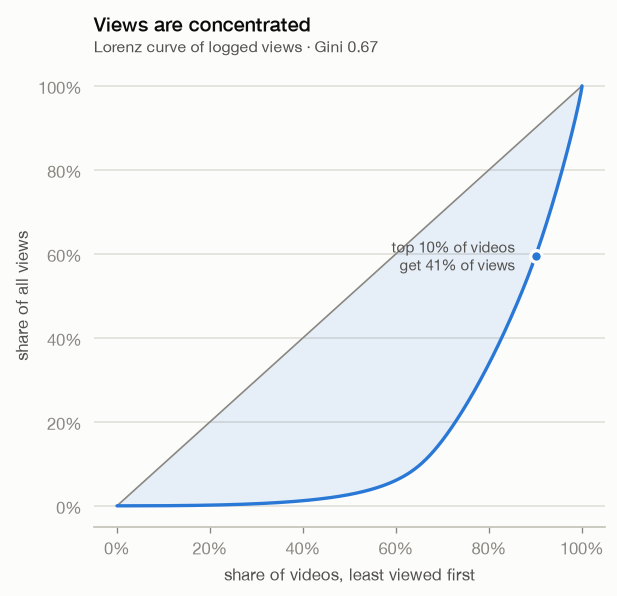

In [8]:
exposure_counts = big.group_by("video_id").len()["len"]
curve = lorenz_curve(exposure_counts)
top10 = top_share(exposure_counts, 0.10)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=style.INK_MUTED, linewidth=1)
ax.plot(curve["share_of_items"], curve["share_of_interactions"], color=style.PRIMARY)
ax.fill_between(
    curve["share_of_items"],
    curve["share_of_interactions"],
    curve["share_of_items"],
    color=style.PRIMARY,
    alpha=style.AREA_ALPHA,
    linewidth=0,
)
ax.plot(
    [0.9],
    [1 - top10],
    marker="o",
    markersize=7,
    color=style.PRIMARY,
    markeredgecolor=style.SURFACE,
    markeredgewidth=2,
)
ax.annotate(
    f"top 10% of videos\nget {top10:.0%} of views",
    (0.9, 1 - top10),
    xytext=(-12, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color=style.INK_SECONDARY,
    fontsize=9,
)
percent_axis(ax.xaxis)
percent_axis(ax.yaxis)
ax.set_xlabel("share of videos, least viewed first")
ax.set_ylabel("share of all views")
style.add_title(
    ax, "Views are concentrated", f"Lorenz curve of logged views · Gini {gini(exposure_counts):.2f}"
)
save(fig, "04_exposure_lorenz_curve")

2 fully observed videos never appear in training


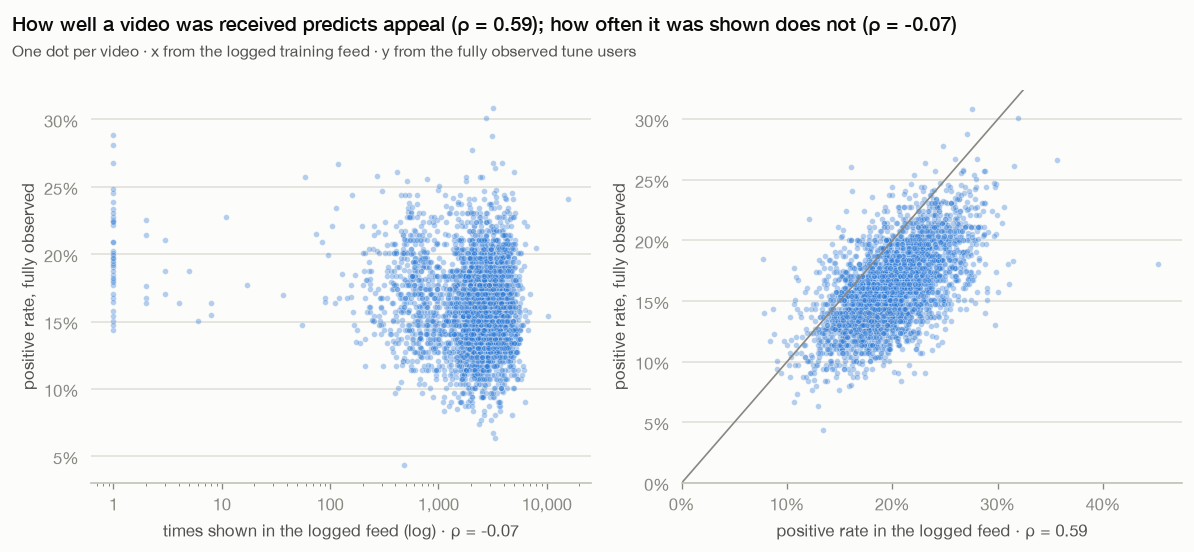

In [9]:
logged = train.group_by("video_id").agg(
    exposures=pl.len(), logged_rate=pl.col("is_positive").mean()
)
appeal = tune.group_by("video_id").agg(appeal=pl.col("is_positive").mean())
per_video = appeal.join(logged, on="video_id", how="left")
print(f"{per_video['exposures'].null_count()} fully observed videos never appear in training")
per_video = per_video.drop_nulls()
reliable = per_video.filter(pl.col("exposures") >= MIN_LOGGED_VIEWS)
rho_exposure = spearman(per_video, "exposures", "appeal")
rho_engagement = spearman(reliable, "logged_rate", "appeal")

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, frame, column in ((left, per_video, "exposures"), (right, reliable, "logged_rate")):
    ax.scatter(
        frame[column],
        frame["appeal"],
        s=12,
        alpha=0.35,
        color=style.PRIMARY,
        edgecolors=style.SURFACE,
        linewidths=0.4,
    )
    percent_axis(ax.yaxis)
    ax.set_ylabel("positive rate, fully observed")
left.set_xscale("log")
left.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
left.set_xlabel(f"times shown in the logged feed (log) · ρ = {rho_exposure:.2f}")
right.plot([0, 1], [0, 1], color=style.INK_MUTED, linewidth=1)
right.set_xlim(0, reliable["logged_rate"].max() * 1.05)
right.set_ylim(0, reliable["appeal"].max() * 1.05)
percent_axis(right.xaxis)
right.set_xlabel(f"positive rate in the logged feed · ρ = {rho_engagement:.2f}")
exposure_verdict = "does not" if abs(rho_exposure) < 0.2 else "also does"
style.add_figure_title(
    fig,
    f"How well a video was received predicts appeal (ρ = {rho_engagement:.2f}); "
    f"how often it was shown {exposure_verdict} (ρ = {rho_exposure:.2f})",
    "One dot per video · x from the logged training feed · y from the fully observed tune users",
)
fig.tight_layout(rect=(0, 0, 1, style.FIGURE_TITLE_TOP))
save(fig, "05_exposure_vs_preference")

In [10]:
pl.DataFrame(
    {
        "videos": ["fully observed", "all others"],
        "median logged views": [
            per_video["exposures"].median(),
            big.join(per_video.select("video_id"), on="video_id", how="anti")
            .group_by("video_id")
            .len()["len"]
            .median(),
        ],
    }
)

videos,median logged views
str,f64
"""fully observed""",2384.0
"""all others""",74.0


**Two signals, two conclusions.** *How often* the old recommender showed a video says little
about how much users like it once everyone sees it, but *how well it was received when shown*
(its logged positive rate) transfers well. For Phase 2 this suggests a hypothesis: popularity
ranked by view count should do poorly on the fully observed users, while popularity ranked by
engagement rate should be a strong baseline.

Scope: the fully observed videos are among the most-shown in the catalogue (table above), so
these correlations describe frequently shown videos, not the long tail.

## 5. Time: collection windows and splits

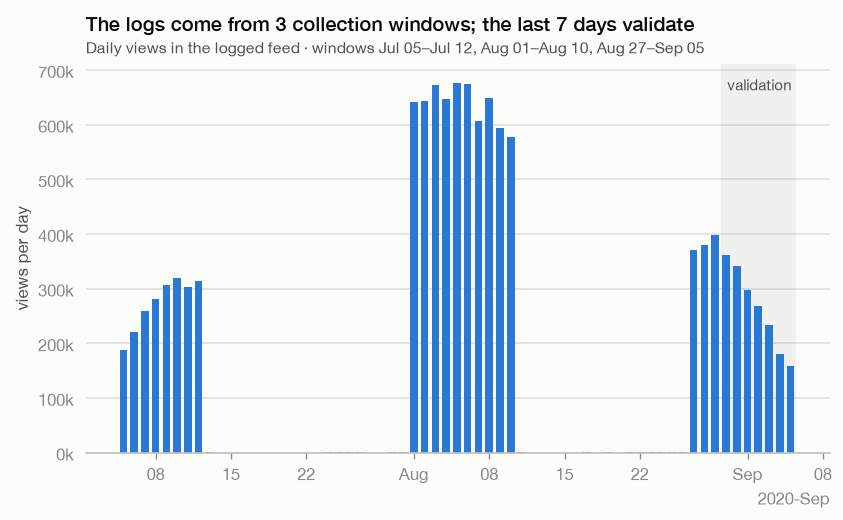

window,start,end,views
u32,date,date,u32
1,2020-07-05,2020-07-12,2191184
2,2020-08-01,2020-08-10,6381114
3,2020-08-27,2020-09-05,2987782


In [11]:
daily = big.group_by(day=pl.col("event_time").dt.date()).agg(views=pl.len()).sort("day")
windows = (
    daily.filter(pl.col("views") >= BUSY_DAY_MIN_VIEWS)
    .with_columns(window=(pl.col("day").diff().dt.total_days() > 1).fill_null(True).cum_sum())
    .group_by("window")
    .agg(start=pl.col("day").min(), end=pl.col("day").max(), views=pl.col("views").sum())
    .sort("start")
)
plotted = daily.filter(pl.col("day").is_between(windows["start"].min(), windows["end"].max()))

fig, ax = plt.subplots(figsize=FIGSIZE)
# Bars are centred on their date, so the shaded span starts and ends half a day out.
ax.axvspan(
    mdates.date2num(VALID_START) - 0.5,
    mdates.date2num(windows["end"].max()) + 0.5,
    color=style.INK_MUTED,
    alpha=style.AREA_ALPHA,
    linewidth=0,
)
ax.annotate(
    "validation",
    (mdates.date2num(VALID_START) - 0.5, 0.97),
    xycoords=("data", "axes fraction"),
    xytext=(4, 0),
    textcoords="offset points",
    va="top",
    color=style.INK_SECONDARY,
    fontsize=9,
)
ax.bar(plotted["day"], plotted["views"], width=0.7, color=style.PRIMARY)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}k"))
ax.set_ylabel("views per day")
window_text = ", ".join(f"{s:%b %d}–{e:%b %d}" for s, e in windows.select("start", "end").rows())
valid_days = (windows["end"].max() - VALID_START).days + 1
style.add_title(
    ax,
    f"The logs come from {windows.height} collection windows; the last {valid_days} days validate",
    f"Daily views in the logged feed · windows {window_text}",
)
save(fig, "06_daily_views_and_split")
windows

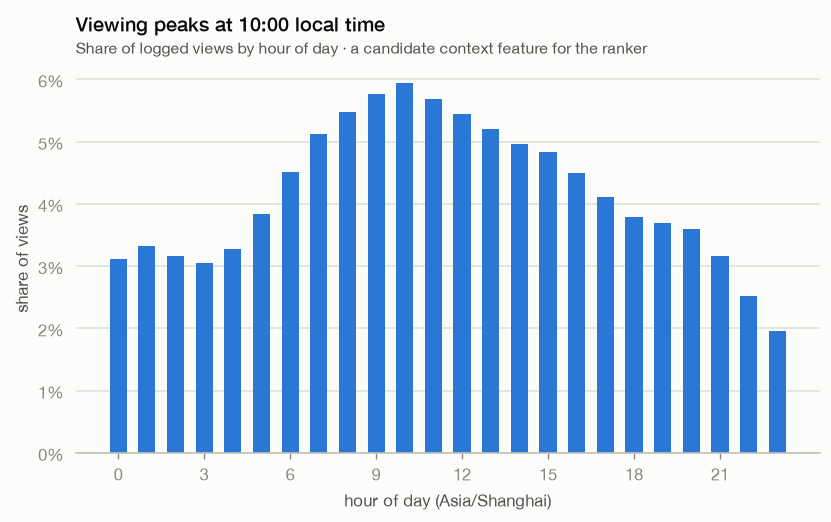

In [12]:
hourly = (
    big.group_by(hour=pl.col("event_time").dt.hour())
    .len()
    .sort("hour")
    .with_columns(share=pl.col("len") / pl.col("len").sum())
)
peak = hourly.sort("share", descending=True).row(0, named=True)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(hourly["hour"], hourly["share"], width=0.6, color=style.PRIMARY)
ax.set_xticks(range(0, 24, 3))
percent_axis(ax.yaxis)
ax.set_xlabel("hour of day (Asia/Shanghai)")
ax.set_ylabel("share of views")
style.add_title(
    ax,
    f"Viewing peaks at {peak['hour']}:00 local time",
    "Share of logged views by hour of day · a candidate context feature for the ranker",
)
save(fig, "07_views_by_hour")

The logged feed was collected in separate windows of 8-10 days with only a few thousand stray
events in between, so "days since last view"-style features must expect multi-week gaps.

**Four splits, four jobs:**

| Split | Source | Used for |
|---|---|---|
| train | logged feed, before the cut-off | fitting models and the label cut-offs |
| valid | logged feed, from the cut-off on | training-time checks such as early stopping |
| tune | fully observed, 20% of users (stable hash) | model selection and this notebook |
| test | fully observed, the other 80% of users | final report and A/B simulation only |

train/valid is a single global time cut-off, so no model trains on events later than those it
is validated on. valid is *not* used for model selection: unlike tune and test it contains
re-watches and cold-start videos, and its exposure was chosen by the old recommender.

In [13]:
pl.DataFrame(
    [
        {
            "split": name,
            "rows": split_summary[name]["rows"],
            "users": split_summary[name]["users"],
            "videos": split_summary[name]["videos"],
            "positive rate": split_summary[name]["positive_rate"],
            "cold-start video rows": split_summary[name].get("cold_start_video_row_share"),
            "repeat-pair rows": split_summary[name].get("repeat_pair_row_share"),
            "time range": (
                f"{split_summary[name]['first_event'][:10]} → "
                f"{split_summary[name]['last_event'][:10]}"
                if "first_event" in split_summary[name]
                else None
            ),
        }
        for name in ("train", "valid", "tune", "test")
    ]
)

split,rows,users,videos,positive rate,cold-start video rows,repeat-pair rows,time range
str,i64,i64,i64,f64,f64,f64,str
"""train""",9722996,7176,9246,0.2,null,null,null
"""valid""",1839806,6922,5476,0.2112,0.1252,0.1375,null
"""tune""",990908,299,3327,0.162,null,null,"""2020-07-05 → 2020-09-05"""
"""test""",3685662,1112,3327,0.152,null,null,"""2020-07-04 → 2020-09-05"""


## 6. Categories: what the feed shows vs. what people like

Both panels use the same videos (those in the fully observed matrix).

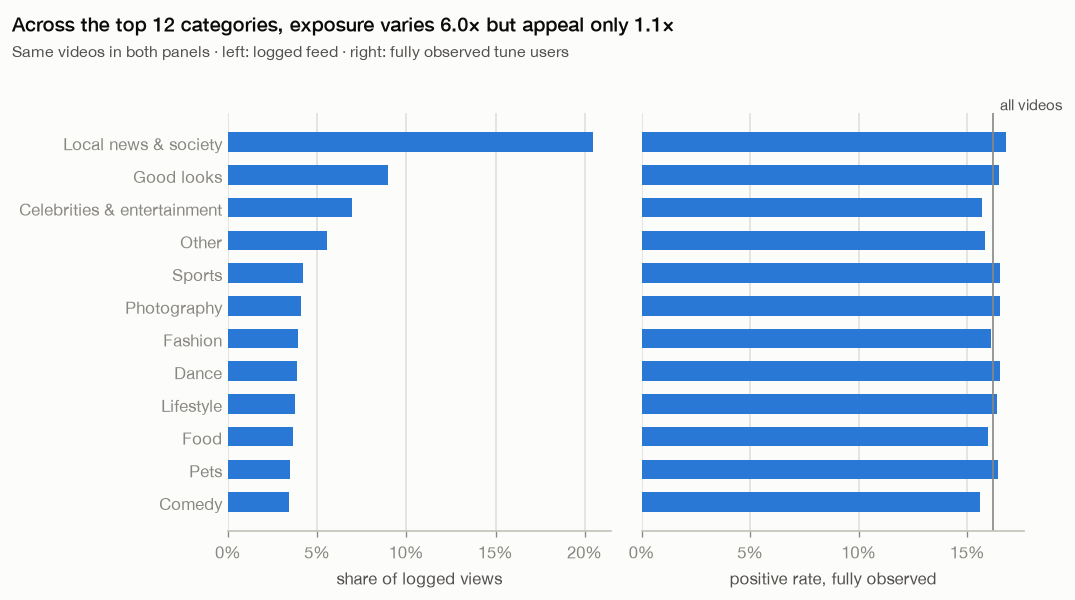

In [14]:
observed_videos = tune.select("video_id").unique()
category_of = captions.select("video_id", "category_en")
logged_by_category = (
    big.join(observed_videos, on="video_id", how="semi")
    .join(category_of, on="video_id")
    .group_by("category_en")
    .len()
    .with_columns(view_share=pl.col("len") / pl.col("len").sum())
)
liked_by_category = (
    tune.join(category_of, on="video_id")
    .group_by("category_en")
    .agg(positive_rate=pl.col("is_positive").mean(), videos=pl.col("video_id").n_unique())
)
by_category = logged_by_category.join(liked_by_category, on="category_en")
top_categories = by_category.sort("view_share", descending=True).head(12).reverse()
exposure_spread = top_categories["view_share"].max() / top_categories["view_share"].min()
appeal_spread = top_categories["positive_rate"].max() / top_categories["positive_rate"].min()
overall_rate = tune["is_positive"].mean()

fig, (left, right) = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
names = top_categories["category_en"].to_list()
left.barh(names, top_categories["view_share"], height=0.6, color=style.PRIMARY)
right.barh(names, top_categories["positive_rate"], height=0.6, color=style.PRIMARY)
right.axvline(overall_rate, color=style.INK_MUTED, linewidth=1)
right.annotate(
    "all videos",
    (overall_rate, 1.0),
    xycoords=("data", "axes fraction"),
    xytext=(4, 0),
    textcoords="offset points",
    va="bottom",
    color=style.INK_SECONDARY,
    fontsize=9,
)
for ax, label in ((left, "share of logged views"), (right, "positive rate, fully observed")):
    percent_axis(ax.xaxis)
    ax.set_xlabel(label)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    ax.tick_params(axis="y", length=0)
style.add_figure_title(
    fig,
    f"Across the top 12 categories, exposure varies {exposure_spread:.1f}× "
    f"but appeal only {appeal_spread:.1f}×",
    "Same videos in both panels · left: logged feed · right: fully observed tune users",
)
fig.tight_layout(rect=(0, 0, 1, style.FIGURE_TITLE_TOP))
save(fig, "08_categories_exposure_vs_appeal")

In [15]:
# Across *all* categories with enough videos, appeal varies more than among the top 12.
by_category.filter(pl.col("videos") >= 20).select(
    categories=pl.len(),
    min_positive_rate=pl.col("positive_rate").min(),
    max_positive_rate=pl.col("positive_rate").max(),
)

categories,min_positive_rate,max_positive_rate
u32,f64,f64
27,0.136349,0.16873


## 7. Limitations to carry into evaluation

In [16]:
per_user_rate = tune.group_by("user_id").agg(rate=pl.col("is_positive").mean())["rate"]
pl.DataFrame(
    {
        "statistic": ["5th percentile", "median", "95th percentile"],
        "per-user positive rate (tune)": [
            per_user_rate.quantile(0.05),
            per_user_rate.median(),
            per_user_rate.quantile(0.95),
        ],
    }
)

statistic,per-user positive rate (tune)
str,f64
"""5th percentile""",0.007824
"""median""",0.125075
"""95th percentile""",0.447487


* **"Fully observed" has a scope.** It covers the videos in small_matrix only (about a third
  of the catalogue, and mostly frequently shown ones), and its users are among the heaviest on
  the platform. Each pair has one reaction, recorded in a feed. The A/B simulation can only
  "recommend" from these videos, and its results describe these users.
* **The test set is not later in time than training.** small_matrix spans the same weeks as
  big_matrix. It measures preferences, not the future; "no training on the future" holds for
  train vs. valid only. Its (user, video) pairs never appear in training.
* **Users differ a lot in how much they watch** (table above), even after the duration fix.
  Pooled metrics such as overall AUC would mostly measure *which users* engage; ranking metrics
  must be computed per user and then averaged.
* **A video's length can differ slightly between log rows** (re-encodes). Labels use each
  row's own length, the same denominator as that row's watch ratio.

## 8. Decisions carried into modelling

| Decision | Choice | Why |
|---|---|---|
| Relevance label | above the 80th-percentile watch ratio of its length bucket (log-spaced, ≤15% wide), fitted on train | raw ratios encode length, not preference (§3) |
| Splits | train/valid by time; tune/test by user within the fully observed matrix | honest validation and selection (§5) |
| Model selection | tune users; test is touched once | valid differs from test (§5) |
| Baselines | popularity by count *and* by engagement rate | exposure ≠ appeal, engagement ≈ appeal (§4) |
| Metrics | per-user ranking metrics + recommendation concentration (Gini) | user propensity varies (§7), popularity bias (§4) |